# XgenePy One-Condition Example

This notebook mirrors the `XgeneR` one-condition vignette using the BATcold Ballinger example data.

In [1]:
from pathlib import Path
import sys

import pandas as pd

repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if (repo_root / 'src').exists() and str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))

from xgenepy import FitObject, fit_edgepython, get_assignments_and_plot, plot_pval_histograms, plot_regulatory_histogram

Load the BATcold counts and metadata from `XgenePy/data`.

In [2]:
data_dir = repo_root / 'data'
counts = pd.read_csv(data_dir / 'BATcold_ballinger_counts.csv', index_col=0)
metadata = pd.read_csv(data_dir / 'BATcold_ballinger_metadata.csv', index_col=0)

counts.shape, metadata.shape

((5970, 24), (24, 1))

Create the fit object and run the edgepython-backed GLM workflow.

In [3]:
fit_obj = FitObject(counts=counts, metadata=metadata, trans_model='log_additive')
fit_obj = fit_edgepython(fit_obj)

fit_obj.raw_pvals[['beta_cis', 'beta_trans']].head()

,beta_cis,beta_trans
ENSMUSG00000000056,0.436510,0.478457
ENSMUSG00000000058,0.649610,0.896638
ENSMUSG00000000078,0.843800,0.100440
ENSMUSG00000000088,0.904014,0.944417
ENSMUSG00000000120,0.582695,0.863282


Generate the p-value and FDR histograms.

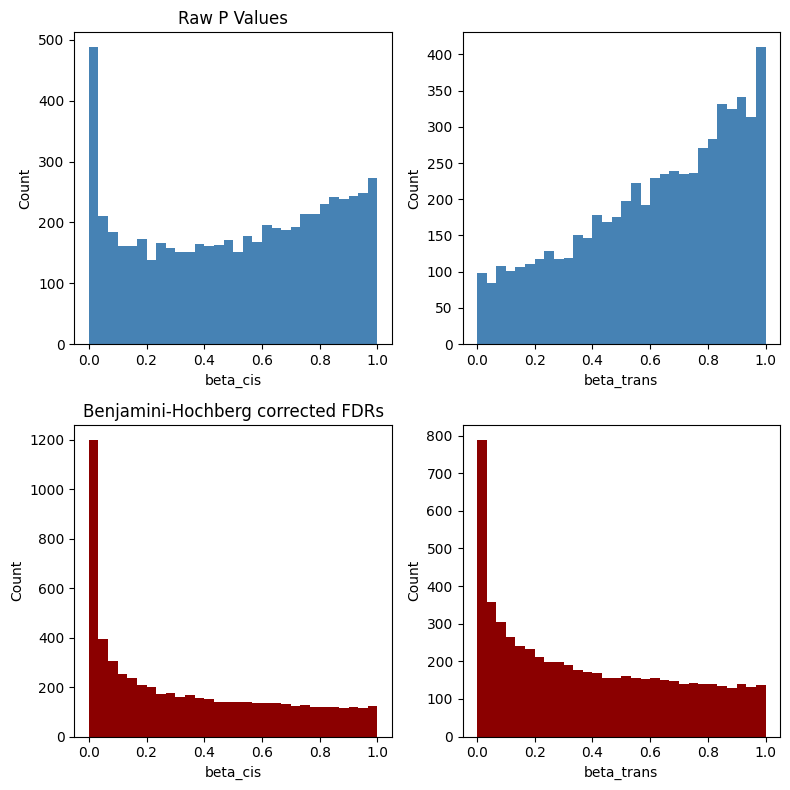

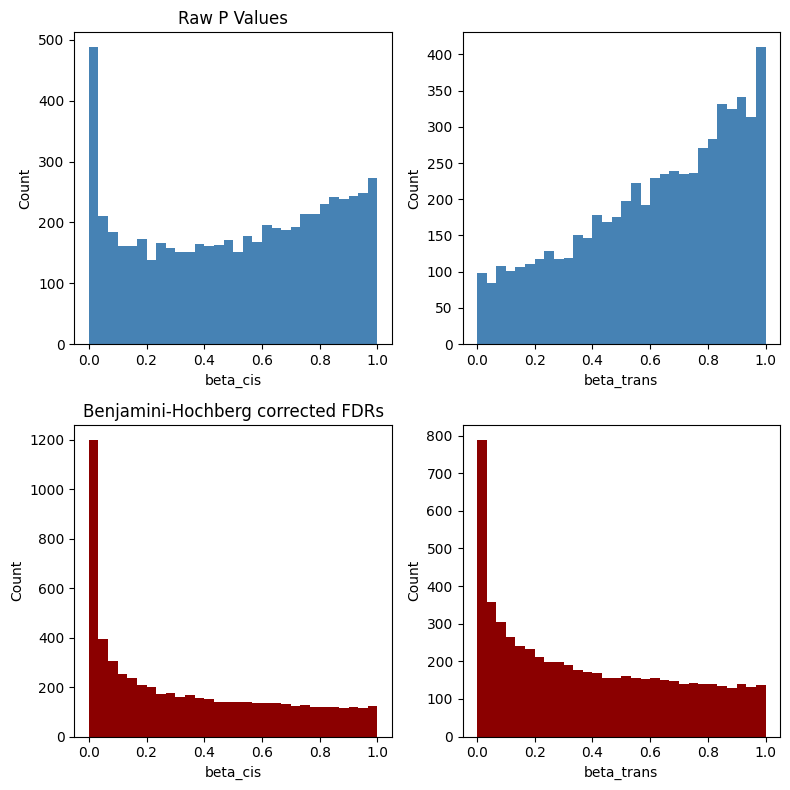

In [4]:
pval_fig = plot_pval_histograms(fit_obj)
pval_fig

Classify genes and view the transformed diagnostic plots plus the proportion-cis values.

,gene,reg_assignment,cis_prop
ENSMUSG00000000056,ENSMUSG00000000056,conserved,1.547166
ENSMUSG00000000058,ENSMUSG00000000058,conserved,1.325838
ENSMUSG00000000078,ENSMUSG00000000078,trans,0.059322
ENSMUSG00000000088,ENSMUSG00000000088,conserved,0.415152
ENSMUSG00000000120,ENSMUSG00000000120,conserved,0.713899


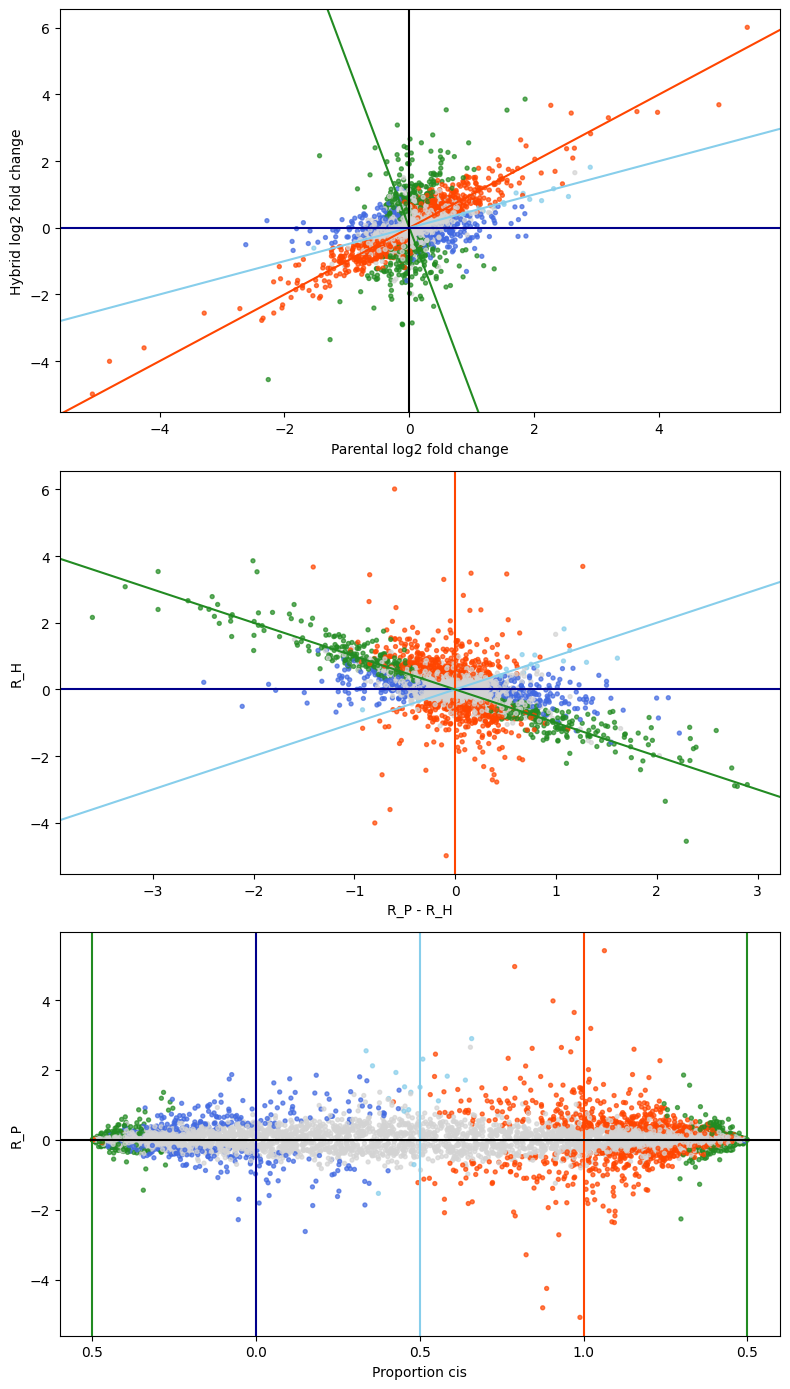

In [5]:
results = get_assignments_and_plot(fit_obj, make_plot=True, alpha=0.05)
results.dataframe[['gene', 'reg_assignment', 'cis_prop']].head()

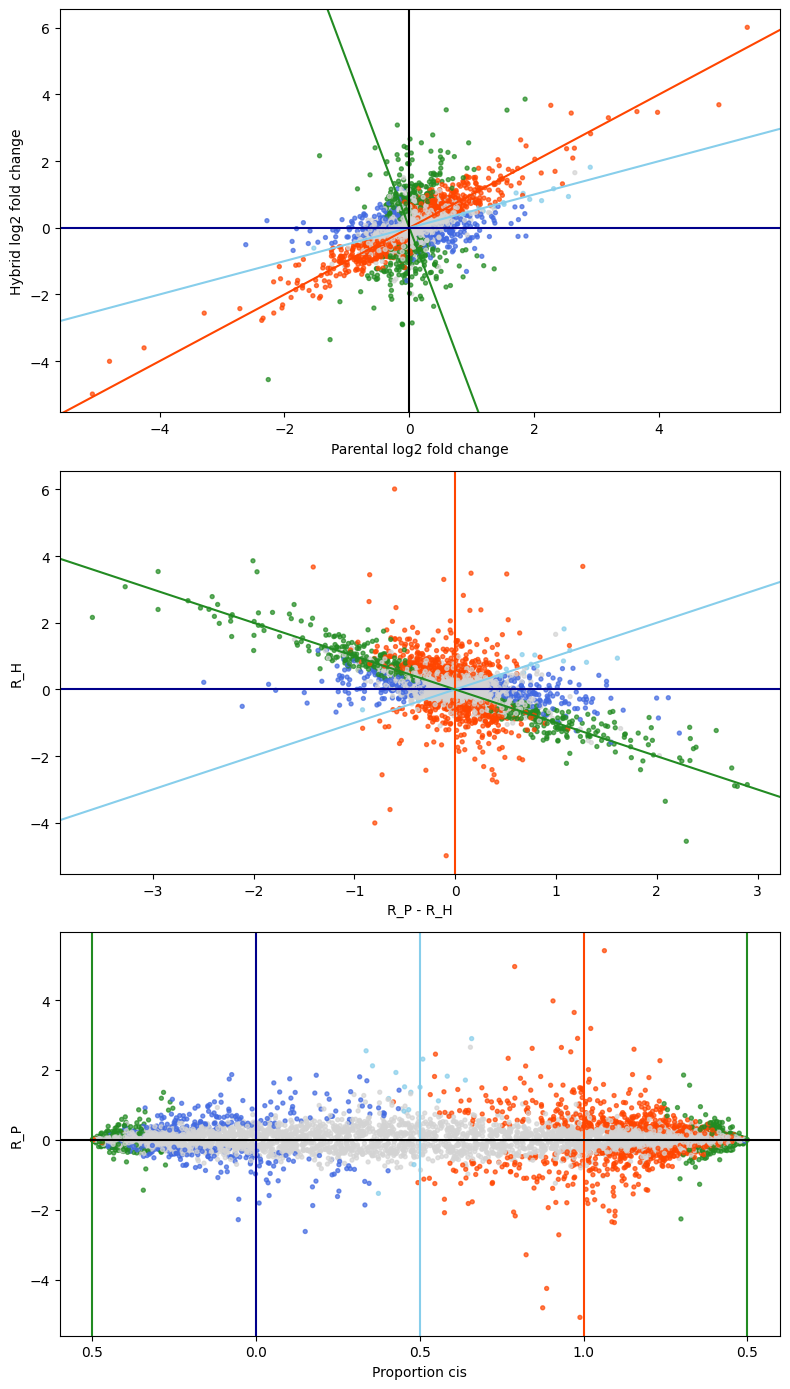

In [6]:
results.figure

Summarize the regulatory assignments.

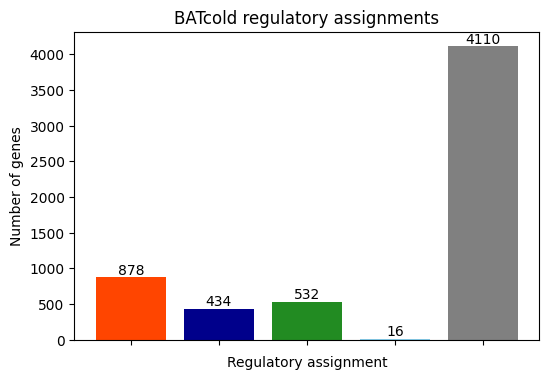

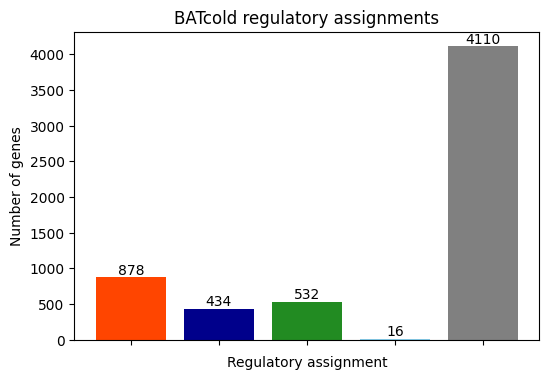

In [7]:
reg_fig = plot_regulatory_histogram(results.dataframe, title='BATcold regulatory assignments')
reg_fig